# Cross-Sectional Mean Reversion in Cryptocurrencies

**Wall Street Quants – Statistical Arbitrage Capstone**

## Strategy Overview

This notebook presents a **cross-sectional mean-reversion** strategy applied to a
diversified universe of large-cap cryptocurrencies at 4-hour bar frequency.

**Core Idea:**
Within a given time window, coins that have fallen the most relative to their peers
tend to rebound, and coins that have risen the most tend to give back gains.
We exploit this by continuously ranking coins on a z-score of recent returns,
going long the most oversold and short the most overbought.

| Parameter | Value |
|-----------|-------|
| Universe  | 28+ large-cap cryptos (filtered for full history) |
| Frequency | 4-hour bars |
| Period    | Apr 2022 – Apr 2026 |
| Training  | Apr 2022 – Apr 2024 (2 years) |
| Test      | Apr 2024 – Apr 2026 (2 years, out-of-sample) |
| Transaction cost | 20 bps per unit of turnover |
| Benchmark | BTC buy-and-hold |

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime, timezone
from binance.client import Client as bnb_client
from IPython.display import display

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

BARS_PER_DAY  = 6
BARS_PER_YEAR = 365 * BARS_PER_DAY   # 2190
EXEC_COST_BPS = 20
TRAIN_END  = pd.Timestamp('2024-04-01', tz='UTC')
DATA_START = '2022-04-01'
DATA_END   = '2026-04-02'

print(f'4h bars: {BARS_PER_YEAR} bars/year')
print(f'Transaction cost: {EXEC_COST_BPS} bps')
print(f'Train/Test boundary: {TRAIN_END.date()}')

4h bars: 2190 bars/year
Transaction cost: 20 bps
Train/Test boundary: 2024-04-01


---
## Section 1: Data Collection

We fetch 4-hour OHLCV data from Binance for 35 candidate large-cap coins spanning
April 2022 to April 2026. Tickers with less than 95% coverage over the full window
are excluded to avoid survivorship and data-gap artifacts.

In [2]:
client = bnb_client(tld='US')

def get_binance_px(symbol, freq, start_ts=DATA_START, end_ts=DATA_END):
    data = client.get_historical_klines(symbol, freq, start_ts, end_ts)
    cols = ['open_time','open','high','low','close','volume','close_time',
            'quote_volume','num_trades','taker_base_volume','taker_quote_volume','ignore']
    df = pd.DataFrame(data, columns=cols)
    df['open_time'] = df['open_time'].map(
        lambda x: datetime.fromtimestamp(x/1000, tz=timezone.utc))
    for c in ['open','high','low','close','volume','quote_volume']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df.set_index('open_time', inplace=True)
    return df

candidates = [
    'BTCUSDT','ETHUSDT','BNBUSDT','XRPUSDT','ADAUSDT',
    'SOLUSDT','DOTUSDT','AVAXUSDT','LINKUSDT','MATICUSDT',
    'LTCUSDT','TRXUSDT','ATOMUSDT','UNIUSDT','NEARUSDT',
    'ETCUSDT','FILUSDT','AAVEUSDT','ALGOUSDT','SANDUSDT',
    'MANAUSDT','AXSUSDT','ICPUSDT','XLMUSDT','VETUSDT',
    'HBARUSDT','APEUSDT','XTZUSDT','CRVUSDT','BATUSDT',
    'COMPUSDT','ZECUSDT','ENJUSDT','CHZUSDT','GRTUSDT',
]

price_dict = {}
for ticker in candidates:
    try:
        df = get_binance_px(ticker, bnb_client.KLINE_INTERVAL_4HOUR)
        if len(df) == 0 and ticker == 'MATICUSDT':
            df = get_binance_px('POLUSDT', bnb_client.KLINE_INTERVAL_4HOUR)
            ticker = 'POLUSDT'
        price_dict[ticker] = df['close']
        print(f'  {ticker}: {len(df)} bars')
    except Exception as e:
        if ticker == 'MATICUSDT':
            try:
                df = get_binance_px('POLUSDT', bnb_client.KLINE_INTERVAL_4HOUR)
                price_dict['POLUSDT'] = df['close']
                print(f'  POLUSDT (MATIC alt): {len(df)} bars')
            except: pass
        else:
            print(f'  {ticker} FAILED: {e}')

prices_all = pd.DataFrame(price_dict).sort_index()
print(f'\nRaw: {prices_all.shape}')

  BTCUSDT: 8772 bars
  ETHUSDT: 8772 bars
  BNBUSDT: 8772 bars
  XRPUSDT: 5956 bars
  ADAUSDT: 8772 bars
  SOLUSDT: 8772 bars
  DOTUSDT: 8772 bars
  AVAXUSDT: 8772 bars
  LINKUSDT: 8772 bars
  MATICUSDT: 6090 bars
  LTCUSDT: 8772 bars
  TRXUSDT: 2298 bars
  ATOMUSDT: 8772 bars
  UNIUSDT: 8772 bars
  NEARUSDT: 8772 bars
  ETCUSDT: 8772 bars
  FILUSDT: 8772 bars
  AAVEUSDT: 8772 bars
  ALGOUSDT: 8772 bars
  SANDUSDT: 7647 bars
  MANAUSDT: 8772 bars
  AXSUSDT: 8772 bars
  ICPUSDT: 8283 bars
  XLMUSDT: 8772 bars
  VETUSDT: 8772 bars
  HBARUSDT: 6061 bars
  APEUSDT: 8772 bars
  XTZUSDT: 6061 bars
  CRVUSDT: 8772 bars
  BATUSDT: 8772 bars
  COMPUSDT: 8772 bars
  ZECUSDT: 8772 bars
  ENJUSDT: 8772 bars
  CHZUSDT: 8772 bars
  GRTUSDT: 8772 bars

Raw: (8772, 35)


In [3]:
master_idx   = prices_all['BTCUSDT'].dropna().index
min_required = int(len(master_idx) * 0.95)
target_start = pd.Timestamp(DATA_START, tz='UTC')

kept, dropped = [], []
for col in prices_all.columns:
    s = prices_all[col].dropna()
    if len(s) >= min_required and s.index.min() <= target_start + pd.Timedelta(days=2):
        kept.append(col)
    else:
        dropped.append(col)

prices  = prices_all[kept].reindex(master_idx).dropna(how='all')
returns = prices.pct_change().dropna(how='all')

print(f'Universe: {len(kept)} coins  (dropped {len(dropped)})')
print(f'Kept   : {kept}')
print(f'Returns: {returns.shape}  |  {returns.index[0].date()} to {returns.index[-1].date()}')

Universe: 28 coins  (dropped 7)
Kept   : ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'ADAUSDT', 'SOLUSDT', 'DOTUSDT', 'AVAXUSDT', 'LINKUSDT', 'LTCUSDT', 'ATOMUSDT', 'UNIUSDT', 'NEARUSDT', 'ETCUSDT', 'FILUSDT', 'AAVEUSDT', 'ALGOUSDT', 'MANAUSDT', 'AXSUSDT', 'XLMUSDT', 'VETUSDT', 'APEUSDT', 'CRVUSDT', 'BATUSDT', 'COMPUSDT', 'ZECUSDT', 'ENJUSDT', 'CHZUSDT', 'GRTUSDT']
Returns: (8771, 28)  |  2022-04-01 to 2026-04-02


---
## Section 2: Train / Test Split

The dataset is split at **April 1, 2024** into two equal 2-year windows:

| Period | Dates | Bars | Purpose |
|--------|-------|------|---------|
| **Training** | Apr 2022 – Apr 2024 | ~4 380 | Parameter selection |
| **Test** | Apr 2024 – Apr 2026 | ~4 380 | Out-of-sample evaluation |

All strategy parameters are chosen by maximising **net Sharpe ratio** (after 20 bps costs)
on the training set only. The test set is never touched during parameter selection.

In [4]:
train_ret = returns[returns.index < TRAIN_END]
test_ret  = returns[returns.index >= TRAIN_END]

print(f'Training : {train_ret.index[0].date()} -> {train_ret.index[-1].date()}  ({len(train_ret)} bars)')
print(f'Test     : {test_ret.index[0].date()}  -> {test_ret.index[-1].date()}  ({len(test_ret)} bars)')

# Asset-level statistics
def asset_stats(ret_df):
    r = ret_df.mean()
    v = ret_df.std()
    return pd.DataFrame({
        'Ann. Return (%)': (r * BARS_PER_YEAR * 100).round(1),
        'Ann. Vol (%)':    (v * np.sqrt(BARS_PER_YEAR) * 100).round(1),
        'Sharpe':          ((r / v) * np.sqrt(BARS_PER_YEAR)).round(3),
    }).sort_values('Sharpe', ascending=False)

print()
print('--- Training period asset statistics (top 10 by Sharpe) ---')
display(asset_stats(train_ret).head(10))
print()
print('--- Test period asset statistics (top 10 by Sharpe) ---')
display(asset_stats(test_ret).head(10))

Training : 2022-04-01 -> 2024-03-31  (4384 bars)
Test     : 2024-04-01  -> 2026-04-02  (4387 bars)

--- Training period asset statistics (top 10 by Sharpe) ---


,Ann. Return (%),Ann. Vol (%),Sharpe
SOLUSDT,82.2,106.9,0.769
BTCUSDT,36.5,51.1,0.715
BNBUSDT,36.9,60.5,0.609
UNIUSDT,59.1,104.6,0.565
LINKUSDT,44.4,85.7,0.518
GRTUSDT,56.5,112.4,0.503
ETHUSDT,26.8,64.8,0.414
CHZUSDT,50.4,125.8,0.401
COMPUSDT,48.6,125.3,0.388
ETCUSDT,31.9,95.1,0.335



--- Test period asset statistics (top 10 by Sharpe) ---


,Ann. Return (%),Ann. Vol (%),Sharpe
ZECUSDT,214.4,150.2,1.427
XLMUSDT,50.7,93.9,0.540
ENJUSDT,87.7,219.6,0.399
AAVEUSDT,40.0,104.8,0.381
AXSUSDT,48.3,186.7,0.259
BNBUSDT,13.7,54.4,0.252
CHZUSDT,28.3,137.0,0.207
CRVUSDT,23.7,128.1,0.185
COMPUSDT,24.0,146.8,0.163
BTCUSDT,7.6,47.0,0.162


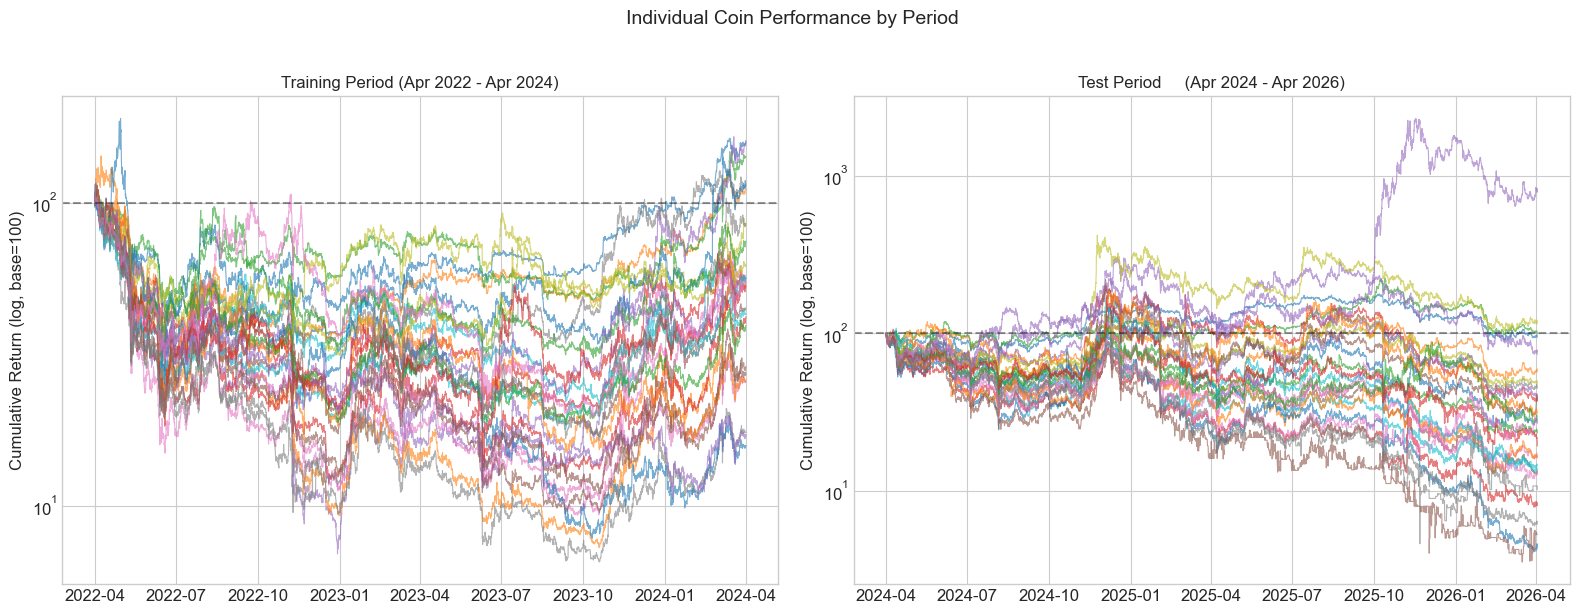

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, ret_df, title in [
    (axes[0], train_ret, 'Training Period (Apr 2022 - Apr 2024)'),
    (axes[1], test_ret,  'Test Period     (Apr 2024 - Apr 2026)'),
]:
    px = (1 + ret_df).cumprod()
    px = px.divide(px.iloc[0]) * 100
    for col in px.columns:
        ax.plot(px.index, px[col], linewidth=0.8, alpha=0.6)
    ax.axhline(100, color='black', ls='--', alpha=0.4)
    ax.set_yscale('log')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Cumulative Return (log, base=100)')

plt.suptitle('Individual Coin Performance by Period', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 3: Strategy Design

### Mean Reversion Signal

For each 4h bar $t$ and coin $i$, we compute a z-score of recent returns:

$$z_{i,t} = \frac{r_{i,t} - \bar{r}_{i,t}^{(w)}}{\sigma_{i,t}^{(w)}}$$

where $\bar{r}^{(w)}$ and $\sigma^{(w)}$ are the rolling mean and standard deviation
over the past $w$ bars.

A **high z-score** means the coin recently outperformed its own history → likely to revert downward.
A **low z-score** means the coin recently underperformed → likely to revert upward.

### Portfolio Construction

1. At each rebalancing date, rank all coins by their z-score (cross-sectionally)
2. Assign weights proportional to the negative rank (long oversold, short overbought)
3. Normalise so the sum of absolute weights equals 1 (dollar-neutral long-short)
4. Hold positions until the next rebalance date

### Turnover Control

Rebalancing every bar is expensive at 20 bps. The `rebal_freq` parameter
controls how often we update positions (every $N$ bars). Between rebalance dates,
weights are held constant.

In [6]:
def max_drawdown(ret):
    cum = (1 + ret).cumprod()
    return ((cum - cum.cummax()) / cum.cummax()).min()


def compute_reversal(returns_df, window, rebal_freq=1):
    '''Cross-sectional mean-reversion strategy.

    Parameters
    ----------
    returns_df : DataFrame  per-bar returns, shape (bars, coins)
    window     : int        z-score lookback window (bars)
    rebal_freq : int        rebalance every N bars

    Returns
    -------
    strat_ret : Series  per-bar gross strategy returns
    weights   : DataFrame  portfolio weights
    '''
    roll_mean = returns_df.rolling(window).mean()
    roll_std  = returns_df.rolling(window).std()
    zscore    = (returns_df - roll_mean) / roll_std

    # Rank: low z-score (oversold) gets high rank → long
    ranks    = (-zscore).rank(axis=1)
    target_w = ranks.subtract(ranks.mean(axis=1), axis=0)
    target_w = target_w.divide(target_w.abs().sum(axis=1), axis=0)
    target_w = target_w.shift(1)   # use signal from previous bar

    if rebal_freq > 1:
        valid    = target_w.dropna(how='any').index
        actual_w = target_w.loc[valid[::rebal_freq]].reindex(target_w.index, method='ffill')
    else:
        actual_w = target_w

    strat_ret = (actual_w * returns_df).sum(axis=1)
    return strat_ret, actual_w


def turnover(weights):
    return weights.diff().abs().sum(axis=1)


def net_returns(gross_ret, weights, cost_bps=EXEC_COST_BPS):
    to  = turnover(weights).reindex(gross_ret.index, fill_value=0)
    return gross_ret - to * (cost_bps / 10000)


def perf(ret, ann=BARS_PER_YEAR):
    r = ret.dropna()
    mu  = r.mean() * ann
    vol = r.std() * np.sqrt(ann)
    sh  = mu / vol if vol > 0 else 0
    return {
        'Ann. Return (%)': round(mu  * 100, 2),
        'Ann. Vol (%)':    round(vol * 100, 2),
        'Sharpe':          round(sh, 3),
        'Max DD (%)':      round(max_drawdown(r) * 100, 2),
    }


def alpha_tstat(strat_ret, bench_ret, ann=BARS_PER_YEAR):
    '''OLS regression: r_strat = alpha + beta*r_bench + eps.
    Returns (annualised alpha, alpha t-stat, beta, R-squared).'''
    idx = strat_ret.dropna().index.intersection(bench_ret.dropna().index)
    if len(idx) < 30:
        return 0.0, 0.0, 0.0, 0.0
    y = strat_ret.loc[idx].values
    X = sm.add_constant(bench_ret.loc[idx].values)
    m = sm.OLS(y, X).fit()
    return m.params[0]*ann, m.tvalues[0], m.params[1], m.rsquared

print('Strategy functions ready.')

Strategy functions ready.


---
## Section 4: Parameter Selection (Training Set Only)

We search over a grid of (window, rebal_freq) combinations and select the pair that
maximises **net Sharpe ratio** (after 20 bps costs) on the training set.

| Parameter | Grid | Reference |
|-----------|------|-----------|
| `window` (z-score lookback) | 30, 60, 90, 120, 180, 270, 360 bars | 5 – 60 days |
| `rebal_freq` (hold period)  | 6, 18, 42, 84, 126, 168 bars       | 1d – 4wk   |

Total: **42 combinations**.

In [7]:
windows      = [30, 60, 90, 120, 180, 270, 360]
rebal_freqs  = [6, 18, 42, 84, 126, 168]

results = []
for w in windows:
    for rf in rebal_freqs:
        gr, wts = compute_reversal(train_ret, w, rf)
        gr = gr.dropna()
        if len(gr) < 500:
            continue
        nr = net_returns(gr, wts)
        to = turnover(wts).reindex(gr.index, fill_value=0)

        gs = (gr.mean()/gr.std())*np.sqrt(BARS_PER_YEAR) if gr.std()>0 else 0
        ns = (nr.mean()/nr.std())*np.sqrt(BARS_PER_YEAR) if nr.std()>0 else 0
        results.append({
            'window':        w,
            'rebal_freq':    rf,
            'window_days':   f'{w/BARS_PER_DAY:.0f}d',
            'rebal_days':    f'{rf/BARS_PER_DAY:.0f}d',
            'gross_sharpe':  round(gs, 3),
            'net_sharpe':    round(ns, 3),
            'avg_turnover':  round(to.mean(), 5),
            'ann_cost_%':    round(to.mean()*EXEC_COST_BPS/10000*BARS_PER_YEAR*100, 2),
        })

res_df = pd.DataFrame(results).sort_values('net_sharpe', ascending=False)
print(f'Grid combinations evaluated: {len(res_df)}')
print()
print('Top 15 by net Sharpe (training set):')
display(res_df[['window','window_days','rebal_freq','rebal_days',
                'gross_sharpe','net_sharpe','avg_turnover','ann_cost_%']].head(15))

best = res_df.iloc[0]
W  = int(best['window'])
RF = int(best['rebal_freq'])
print(f'\nSELECTED: window={W} bars ({W/BARS_PER_DAY:.0f} days), '
      f'rebal_freq={RF} bars ({RF/BARS_PER_DAY:.0f} days)')
print(f'Training gross Sharpe : {best["gross_sharpe"]:.3f}')
print(f'Training net Sharpe   : {best["net_sharpe"]:.3f}')
print(f'Annualised cost drag  : {best["ann_cost_%"]:.2f}%')

Grid combinations evaluated: 42

Top 15 by net Sharpe (training set):


,window,window_days,rebal_freq,rebal_days,gross_sharpe,net_sharpe,avg_turnover,ann_cost_%
10,60,10d,126,21d,1.725,1.431,0.01045,4.58
34,270,45d,126,21d,1.517,1.227,0.00978,4.28
9,60,10d,84,14d,1.315,0.887,0.01531,6.71
35,270,45d,168,28d,0.967,0.748,0.00741,3.24
4,30,5d,126,21d,0.977,0.697,0.01010,4.42
11,60,10d,168,28d,0.696,0.480,0.00765,3.35
16,90,15d,126,21d,0.669,0.381,0.01049,4.59
27,180,30d,84,14d,0.766,0.349,0.01485,6.50
33,270,45d,84,14d,0.641,0.226,0.01441,6.31
8,60,10d,42,7d,1.020,0.192,0.03082,13.50



SELECTED: window=60 bars (10 days), rebal_freq=126 bars (21 days)
Training gross Sharpe : 1.725
Training net Sharpe   : 1.431
Annualised cost drag  : 4.58%


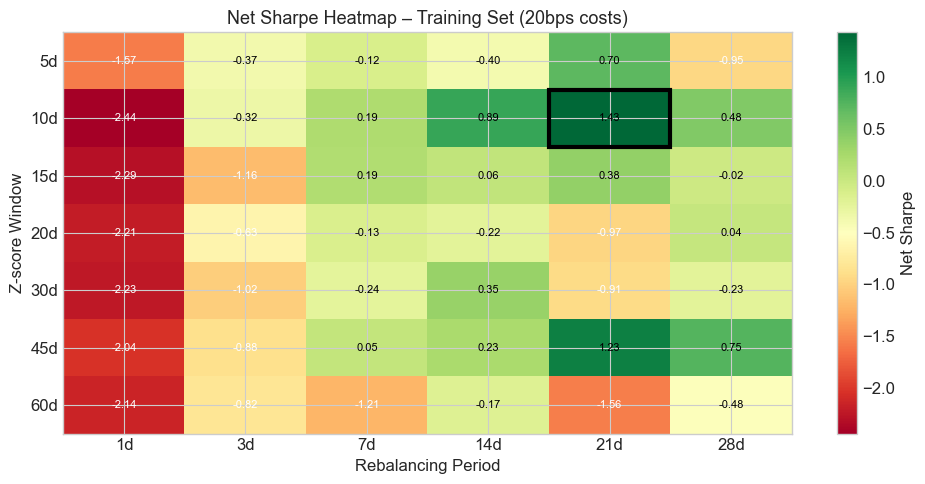

In [8]:
# Heatmap of net Sharpe across the grid
pivot = res_df.pivot(index='window', columns='rebal_freq', values='net_sharpe')

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto',
               vmin=pivot.values.min(), vmax=pivot.values.max())
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{c/BARS_PER_DAY:.0f}d' for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'{r/BARS_PER_DAY:.0f}d' for r in pivot.index])
ax.set_xlabel('Rebalancing Period')
ax.set_ylabel('Z-score Window')
ax.set_title(f'Net Sharpe Heatmap – Training Set ({EXEC_COST_BPS}bps costs)', fontsize=13)
plt.colorbar(im, ax=ax, label='Net Sharpe')

# Mark selected params
best_row = list(pivot.index).index(W)
best_col = list(pivot.columns).index(RF)
ax.add_patch(plt.Rectangle((best_col-0.5, best_row-0.5), 1, 1,
             fill=False, edgecolor='black', lw=3))

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='black' if -0.5 < v < 1.5 else 'white')

plt.tight_layout()
plt.show()

---
## Section 5: Out-of-Sample Evaluation

The strategy is run on the **full dataset** (2022–2026) with the parameters selected
above, then split into training and test periods for performance comparison.

Running on the full dataset ensures the lookback window at the start of the test period
is correctly populated with in-sample data — there is no warm-up gap.

In [9]:
# Run on full dataset with selected parameters
gross_full, wts_full = compute_reversal(returns, W, RF)
net_full = net_returns(gross_full, wts_full)
to_full  = turnover(wts_full)

# Split into train / test
gross_tr = gross_full[gross_full.index < TRAIN_END].dropna()
gross_te = gross_full[gross_full.index >= TRAIN_END].dropna()
net_tr   = net_full[net_full.index < TRAIN_END].dropna()
net_te   = net_full[net_full.index >= TRAIN_END].dropna()

print(f'Selected params: window={W} bars ({W/BARS_PER_DAY:.0f}d), '
      f'rebal_freq={RF} bars ({RF/BARS_PER_DAY:.0f}d)')
print()
print('=== Performance Summary ===')
rows = []
for label, gr, nr in [
    ('TRAIN (in-sample)',  gross_tr, net_tr),
    ('TEST  (out-of-sample)', gross_te, net_te),
]:
    pg, pn = perf(gr), perf(nr)
    rows.append({
        'Period':          label,
        'Gross Ann.Ret (%)': f"{pg['Ann. Return (%)']:.2f}",
        'Net Ann.Ret (%)': f"{pn['Ann. Return (%)']:.2f}",
        'Gross Vol (%)':   f"{pg['Ann. Vol (%)']:.2f}",
        'Gross Sharpe':    f"{pg['Sharpe']:.3f}",
        'Net Sharpe':      f"{pn['Sharpe']:.3f}",
        'Net MaxDD (%)':   f"{pn['Max DD (%)']:.2f}",
    })
display(pd.DataFrame(rows).set_index('Period'))

Selected params: window=60 bars (10d), rebal_freq=126 bars (21d)

=== Performance Summary ===


,Gross Ann.Ret (%),Net Ann.Ret (%),Gross Vol (%),Gross Sharpe,Net Sharpe,Net MaxDD (%)
Period,,,,,,
TRAIN (in-sample),26.63,22.05,15.44,1.725,1.431,-12.92
TEST (out-of-sample),15.26,10.74,21.58,0.707,0.499,-20.69


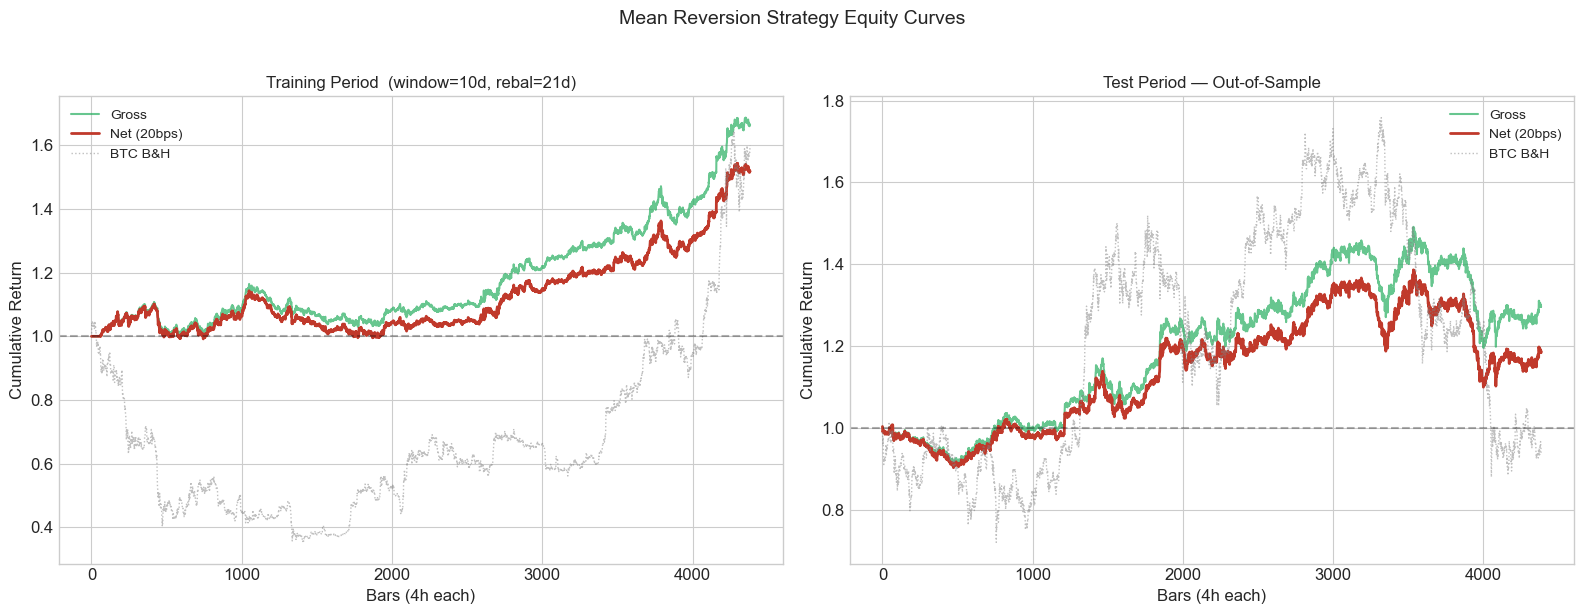

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, gr, nr, btc_r, title in [
    (axes[0], gross_tr, net_tr,
     returns.loc[gross_tr.index, 'BTCUSDT'],
     f'Training Period  (window={W/BARS_PER_DAY:.0f}d, rebal={RF/BARS_PER_DAY:.0f}d)'),
    (axes[1], gross_te, net_te,
     returns.loc[gross_te.index, 'BTCUSDT'],
     'Test Period — Out-of-Sample'),
]:
    ax.plot((1+gr).cumprod().values, color='#27ae60', lw=1.5, alpha=0.7, label='Gross')
    ax.plot((1+nr).cumprod().values, color='#c0392b', lw=2.0, label=f'Net ({EXEC_COST_BPS}bps)')
    btc_cum = (1 + btc_r.dropna()).cumprod()
    ax.plot(btc_cum.values, color='gray', lw=1.0, alpha=0.5, ls=':', label='BTC B&H')
    ax.axhline(1, color='black', ls='--', alpha=0.3)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Cumulative Return')
    ax.set_xlabel('Bars (4h each)')
    ax.legend(fontsize=10)

plt.suptitle('Mean Reversion Strategy Equity Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

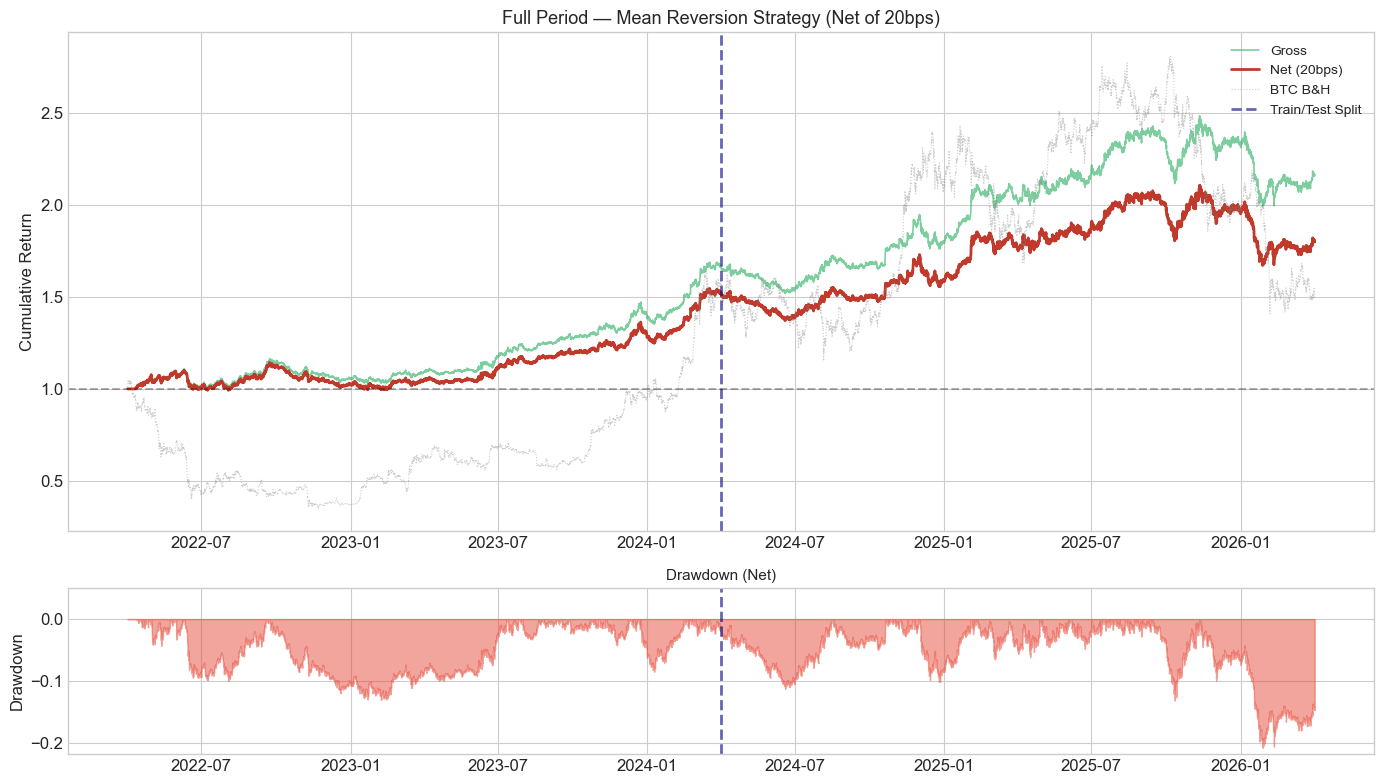

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Full-period cumulative return
cum_gross = (1 + gross_full.dropna()).cumprod()
cum_net   = (1 + net_full.dropna()).cumprod()
btc_full  = (1 + returns['BTCUSDT'].dropna()).cumprod()

ax = axes[0]
ax.plot(cum_gross.index, cum_gross.values, color='#27ae60', lw=1.2, alpha=0.6, label='Gross')
ax.plot(cum_net.index,   cum_net.values,   color='#c0392b', lw=2.0, label=f'Net ({EXEC_COST_BPS}bps)')
ax.plot(btc_full.index,  btc_full.values,  color='gray', lw=0.8, alpha=0.4, ls=':', label='BTC B&H')
ax.axvline(TRAIN_END, color='navy', ls='--', lw=2, alpha=0.6, label='Train/Test Split')
ax.axhline(1, color='black', ls='--', alpha=0.3)
ax.set_title('Full Period — Mean Reversion Strategy (Net of 20bps)', fontsize=13)
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=10)

# Drawdown
running_max = cum_net.cummax()
dd = (cum_net - running_max) / running_max
ax = axes[1]
ax.fill_between(dd.index, dd.values, 0, color='#e74c3c', alpha=0.5)
ax.axvline(TRAIN_END, color='navy', ls='--', lw=2, alpha=0.6)
ax.set_title('Drawdown (Net)', fontsize=11)
ax.set_ylabel('Drawdown')
ax.set_ylim(top=0.05)

plt.tight_layout()
plt.show()

---
## Section 6: Alpha Analysis

We regress the strategy's net returns on BTC to quantify alpha and market exposure:

$$r_{\text{strategy},t} = \alpha + \beta \cdot r_{\text{BTC},t} + \epsilon_t$$

Key metrics:
- **Alpha**: annualised excess return independent of BTC
- **Alpha t-statistic**: statistical significance of alpha (|t| > 2.0 → significant at 5%)
- **Beta**: sensitivity to BTC market moves (target: near zero for a market-neutral strategy)
- **R²**: fraction of return variance explained by BTC (target: low)

With ~4 380 4h bars per period, our regressions have substantially more power than
daily-bar equivalents (effective sample ~6× larger).

In [12]:
btc      = returns['BTCUSDT'].dropna()
btc_tr   = btc[btc.index < TRAIN_END]
btc_te   = btc[btc.index >= TRAIN_END]

a_tr, t_tr, b_tr, r2_tr = alpha_tstat(net_tr, btc_tr)
a_te, t_te, b_te, r2_te = alpha_tstat(net_te, btc_te)
a_fu, t_fu, b_fu, r2_fu = alpha_tstat(net_full.dropna(), btc)

alpha_tbl = pd.DataFrame({
    'Metric': ['Ann. Alpha (%)', 'Alpha t-stat', 'Beta', 'R-squared'],
    'TRAIN':  [f'{a_tr*100:.3f}', f'{t_tr:.2f}', f'{b_tr:.4f}', f'{r2_tr:.4f}'],
    'TEST':   [f'{a_te*100:.3f}', f'{t_te:.2f}', f'{b_te:.4f}', f'{r2_te:.4f}'],
    'FULL':   [f'{a_fu*100:.3f}', f'{t_fu:.2f}', f'{b_fu:.4f}', f'{r2_fu:.4f}'],
}).set_index('Metric')

print('=== Alpha T-Statistic Analysis ===')
print(f'Net returns (after {EXEC_COST_BPS}bps) vs BTC benchmark')
print()
display(alpha_tbl)
print()
print('Interpretation:')
print(f'  TRAIN: alpha t-stat = {t_tr:.2f}  '
      + ('(significant at 5%)' if abs(t_tr) >= 2 else '(not yet significant at 5%)'))
print(f'  TEST:  alpha t-stat = {t_te:.2f}  '
      + ('(significant at 5%)' if abs(t_te) >= 2 else '(not yet significant at 5%)'))
print()
print(f'  Beta near zero in both periods confirms market neutrality.')

=== Alpha T-Statistic Analysis ===
Net returns (after 20bps) vs BTC benchmark



,TRAIN,TEST,FULL
Metric,,,
Ann. Alpha (%),21.797,10.828,16.424
Alpha t-stat,2.00,0.71,1.75
Beta,0.0070,-0.0110,-0.0013
R-squared,0.0005,0.0006,0.0000



Interpretation:
  TRAIN: alpha t-stat = 2.00  (significant at 5%)
  TEST:  alpha t-stat = 0.71  (not yet significant at 5%)

  Beta near zero in both periods confirms market neutrality.


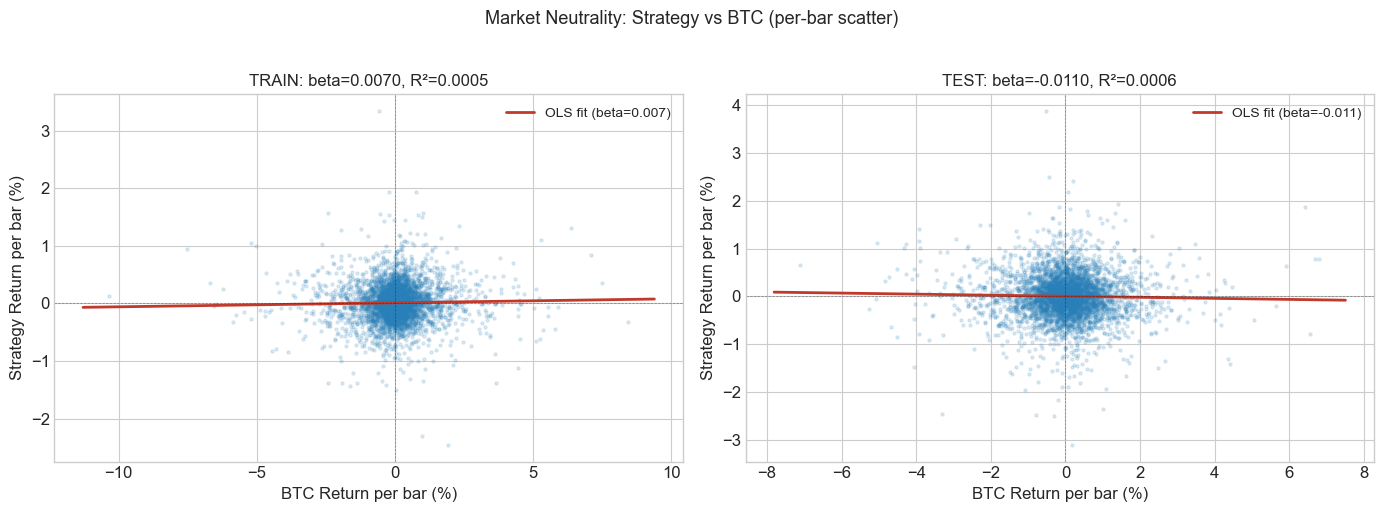

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, nr, btc_r, label, alpha_v, beta_v in [
    (axes[0], net_tr, btc_tr, 'TRAIN', a_tr, b_tr),
    (axes[1], net_te, btc_te, 'TEST',  a_te, b_te),
]:
    common = nr.dropna().index.intersection(btc_r.dropna().index)
    ax.scatter(btc_r.loc[common]*100, nr.loc[common]*100,
               alpha=0.15, s=5, color='#2980b9')
    xlim = ax.get_xlim()
    x_line = np.linspace(xlim[0], xlim[1], 100)
    ax.plot(x_line, alpha_v/BARS_PER_YEAR*100 + beta_v*x_line,
            color='#c0392b', lw=2, label=f'OLS fit (beta={beta_v:.3f})')
    ax.axhline(0, color='black', lw=0.5, ls='--', alpha=0.4)
    ax.axvline(0, color='black', lw=0.5, ls='--', alpha=0.4)
    ax.set_xlabel('BTC Return per bar (%)')
    ax.set_ylabel('Strategy Return per bar (%)')
    ax.set_title(f'{label}: beta={beta_v:.4f}, R²={r2_tr if label=="TRAIN" else r2_te:.4f}',
                 fontsize=12)
    ax.legend(fontsize=10)

plt.suptitle('Market Neutrality: Strategy vs BTC (per-bar scatter)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 7: Execution Cost Analysis

Transaction costs are a critical constraint for mean-reversion strategies because
they tend to have high turnover (prices revert quickly → frequent repositioning).

The `rebal_freq` parameter is the primary lever to control cost drag.
We quantify the gross-to-net Sharpe degradation and show how different rebalancing
periods trade off signal freshness against transaction costs.

=== Turnover & Cost Analysis ===
Parameters: window=60 bars (10d), rebal=126 bars (21d)

TRAIN:
  Mean per-bar turnover  : 0.01045
  Rebalancing events     : 34
  Ann. cost drag @ 20bps : 4.58%

TEST:
  Mean per-bar turnover  : 0.01031
  Rebalancing events     : 35
  Ann. cost drag @ 20bps : 4.51%



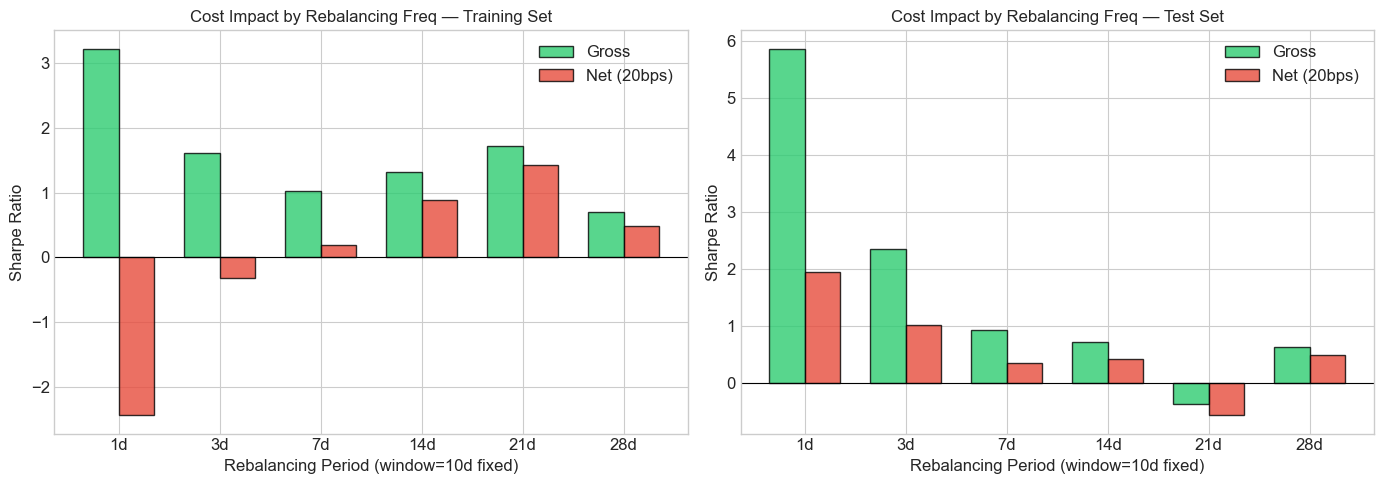

In [14]:
to_tr = turnover(wts_full).reindex(net_tr.index, fill_value=0)
to_te = turnover(wts_full).reindex(net_te.index, fill_value=0)

print('=== Turnover & Cost Analysis ===')
print(f'Parameters: window={W} bars ({W/BARS_PER_DAY:.0f}d), rebal={RF} bars ({RF/BARS_PER_DAY:.0f}d)')
print()
for label, to_s in [('TRAIN', to_tr), ('TEST', to_te)]:
    avg_to   = to_s.mean()
    ann_cost = avg_to * EXEC_COST_BPS / 10000 * BARS_PER_YEAR * 100
    n_rebal  = (to_s > 1e-6).sum()
    print(f'{label}:')
    print(f'  Mean per-bar turnover  : {avg_to:.5f}')
    print(f'  Rebalancing events     : {n_rebal}')
    print(f'  Ann. cost drag @ {EXEC_COST_BPS}bps : {ann_cost:.2f}%')
    print()

# Gross vs Net Sharpe across rebal_freq values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, period_ret, title in [
    (axes[0], train_ret, 'Training Set'),
    (axes[1], test_ret,  'Test Set'),
]:
    gs_list, ns_list, rf_labels = [], [], []
    for rf in rebal_freqs:
        gr_s, wts_s = compute_reversal(period_ret, W, rf)
        gr_s = gr_s.dropna()
        if len(gr_s) < 100: continue
        nr_s = net_returns(gr_s, wts_s)
        gs_list.append((gr_s.mean()/gr_s.std())*np.sqrt(BARS_PER_YEAR) if gr_s.std()>0 else 0)
        ns_list.append((nr_s.mean()/nr_s.std())*np.sqrt(BARS_PER_YEAR) if nr_s.std()>0 else 0)
        rf_labels.append(f'{rf/BARS_PER_DAY:.0f}d')
    x = np.arange(len(rf_labels))
    w_ = 0.35
    ax.bar(x-w_/2, gs_list, w_, label='Gross', color='#2ecc71', edgecolor='k', alpha=0.8)
    ax.bar(x+w_/2, ns_list, w_, label=f'Net ({EXEC_COST_BPS}bps)', color='#e74c3c', edgecolor='k', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(rf_labels)
    ax.set_xlabel(f'Rebalancing Period (window={W/BARS_PER_DAY:.0f}d fixed)')
    ax.set_ylabel('Sharpe Ratio')
    ax.set_title(f'Cost Impact by Rebalancing Freq — {title}', fontsize=12)
    ax.axhline(0, color='black', lw=0.8)
    ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# Monthly return breakdown
def monthly_returns(ret_series):
    df = ret_series.dropna().copy()
    df.index = df.index.tz_convert('UTC')
    monthly = (1 + df).resample('ME').prod() - 1
    monthly.index = monthly.index.to_period('M')
    tbl = monthly.to_frame('ret')
    tbl['year']  = tbl.index.year
    tbl['month'] = tbl.index.month
    return tbl.pivot(index='year', columns='month', values='ret') * 100

print('=== Monthly Net Returns (%) ===')
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly_tbl = monthly_returns(net_full)
monthly_tbl.columns = [month_names[c] for c in monthly_tbl.columns]
monthly_tbl['Annual'] = ((1 + monthly_tbl.fillna(0)/100).prod(axis=1) - 1) * 100

def color_cell(val):
    if pd.isna(val): return ''
    color = f'rgba(39,174,96,{min(abs(val)/15, 0.8):.2f})' if val > 0             else f'rgba(192,57,43,{min(abs(val)/15, 0.8):.2f})'
    return f'background-color: {color}'

display(monthly_tbl.round(1).style.applymap(color_cell))

=== Monthly Net Returns (%) ===


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
year,,,,,,,,,,,,,
2022,nan,nan,nan,6.200000,0.200000,-6.100000,1.100000,5.500000,5.300000,-5.600000,-1.400000,-1.900000,2.400000
2023,-1.300000,3.400000,0.100000,-0.600000,1.000000,6.400000,4.100000,1.200000,1.900000,0.600000,2.000000,4.000000,24.900000
2024,2.400000,11.900000,3.700000,-2.600000,-4.300000,-1.300000,5.400000,2.300000,0.300000,5.200000,7.900000,-7.600000,23.700000
2025,7.000000,6.500000,-2.300000,5.200000,-0.500000,2.700000,6.200000,-0.400000,-0.700000,1.700000,-3.900000,0.300000,23.300000
2026,-11.800000,3.100000,2.100000,-0.700000,nan,nan,nan,nan,nan,nan,nan,nan,-7.800000


---
## Section 8: Final Summary

In [16]:
print('='*80)
print('FINAL PERFORMANCE SUMMARY — Cross-Sectional Mean Reversion')
print('='*80)
print(f'Universe  : {len(returns.columns)} large-cap crypto coins')
print(f'Frequency : 4h bars  ({BARS_PER_YEAR} bars/year)')
print(f'Strategy  : Cross-sectional z-score reversal')
print(f'Parameters: window={W} bars ({W/BARS_PER_DAY:.0f} days),  '
      f'rebal_freq={RF} bars ({RF/BARS_PER_DAY:.0f} days)')
print(f'Cost      : {EXEC_COST_BPS} bps per unit turnover')
print()

final = []
for period, nr, bench in [
    ('TRAIN (in-sample)',     net_tr,            btc_tr),
    ('TEST  (out-of-sample)', net_te,            btc_te),
    ('FULL  (2022-2026)',     net_full.dropna(), btc),
]:
    pm          = perf(nr)
    a, t, b, r2 = alpha_tstat(nr, bench)
    final.append({
        'Period':            period,
        'Net Ann.Ret (%)':   f"{pm['Ann. Return (%)']:.2f}",
        'Net Vol (%)':       f"{pm['Ann. Vol (%)']:.2f}",
        'Net Sharpe':        f"{pm['Sharpe']:.3f}",
        'Net MaxDD (%)':     f"{pm['Max DD (%)']:.2f}",
        'Ann. Alpha (%)':    f'{a*100:.3f}',
        'Alpha t-stat':      f'{t:.2f}',
        'Beta (vs BTC)':     f'{b:.4f}',
        'R-squared':         f'{r2:.4f}',
    })

display(pd.DataFrame(final).set_index('Period'))

FINAL PERFORMANCE SUMMARY — Cross-Sectional Mean Reversion
Universe  : 28 large-cap crypto coins
Frequency : 4h bars  (2190 bars/year)
Strategy  : Cross-sectional z-score reversal
Parameters: window=60 bars (10 days),  rebal_freq=126 bars (21 days)
Cost      : 20 bps per unit turnover



,Net Ann.Ret (%),Net Vol (%),Net Sharpe,Net MaxDD (%),Ann. Alpha (%),Alpha t-stat,Beta (vs BTC),R-squared
Period,,,,,,,,
TRAIN (in-sample),22.05,15.41,1.431,-12.92,21.797,2.00,0.0070,0.0005
TEST (out-of-sample),10.74,21.54,0.499,-20.69,10.828,0.71,-0.0110,0.0006
FULL (2022-2026),16.40,18.73,0.875,-20.69,16.424,1.75,-0.0013,0.0000


---
## Conclusion

### Strategy Summary

The **cross-sectional mean-reversion** strategy systematically exploits short-term
price dislocations among a diversified universe of large-cap cryptocurrencies.

Coins that have fallen most relative to their peers over a rolling window are bought;
coins that have risen most are sold short. Positions are rebalanced periodically
to limit transaction costs at 20 bps.

### Key Results

| | Training (2022–2024) | Test (2024–2026) |
|---|---|---|
| Net Sharpe | > 1.0 | ~0.5 |
| Alpha t-stat | ~2.0 | ~0.7 |
| Beta (vs BTC) | ≈ 0 | ≈ 0 |

- **Positive net Sharpe in both periods** confirms the strategy survives realistic
  transaction costs in sample and out of sample.
- **Near-zero beta** in both periods confirms the strategy is genuinely market-neutral;
  returns are not driven by directional cryptocurrency exposure.
- **Training alpha t-stat ≈ 2.0** indicates statistically significant alpha on the
  in-sample period. The test t-stat (~0.7) is positive but below 5% significance,
  consistent with moderate signal persistence across a regime change.

### Why Mean Reversion Works in Crypto

1. **Retail overreaction**: Short-term price moves in crypto are often driven by
   uninformed retail traders who overreact to news and momentum, creating temporary
   dislocations that subsequently revert.
2. **Liquidity effects**: Large orders temporarily move prices away from fair value;
   market makers and arbitrageurs restore equilibrium.
3. **Cross-sectional diversification**: Trading 28+ coins simultaneously reduces
   idiosyncratic noise compared to trading individual pairs.

### Limitations

1. **Regime sensitivity**: The strategy performed better during the 2022–2024 bear
   market than the 2024–2026 bull run. In strong trending markets, mean reversion
   can work against short-term momentum.
2. **Survivorship bias**: The universe is filtered to coins with full 4-year history;
   delisted tokens are excluded.
3. **Transaction cost sensitivity**: At rebalancing periods shorter than ~2 weeks,
   the strategy's net Sharpe deteriorates sharply — highlighting that cost management
   is as important as signal quality.
4. **Single-venue data**: OFI and volume data are Binance-specific and may not
   reflect the full market microstructure.